![PNS](http://caillau.perso.math.cnrs.fr/logo-pns.png)
## MAM5-INUM - Commande optimale
# TP 1 - Navigation problem (a.k.a. Zermelo-Markov-Dubins)
### Special thanks: P. Negre & M. Sadak (Polytech Nice Sophia)

One considers a ship in a constant current, $0 \leq w \lt 1$. The angle of the velocity (wrt. to the water) is controlled, leading to the following dynamics:

$$ \begin{array}{rcl}
     \dot{x}(t) &=& w+\cos\theta(t),\quad t \in [0,t_f]\\
     \dot{y}(t) &=& \sin\theta(t),\\
     \dot{\theta}(t) &=& u(t). 
   \end{array} $$

The turning rate (= curvature of turns) is limited, so $|u(t)| \leq 1$. There boundary conditions at $t=0$ and $t=t_f$ on the position $(x,y)$ and on the angle $\theta$ of the velocity in the water referential. The final time is to be minimised. The problem originates from a collaboration with the French company [CGG](https://www.cgg.com) that is interested in optimal maneuvers for very large ships doing marine prospection.

![ship](ship.png)

In [5]:
#JuMP model, Ipopt solver
using JuMP, Ipopt, Plots

sys = Model(optimizer_with_attributes(Ipopt.Optimizer,"print_level"=> 5))
set_optimizer_attribute(sys,"tol",1e-6)
set_optimizer_attribute(sys,"max_iter",1000)

# Parameters
w = 0.8
x0 = 0 
y0 = 0 
θ0 = π/7
xf = 4
yf = 7
θf =-π/2 
P = 200

# Bounds for variables

@variables(sys,begin
    x[1:P]           # x 
    y[1:P]           # y 
    θ[1:P]           # theta
    -1 ≤ u[1:P] ≤ 1  # u, control
     0 ≤ Δt ≤ 1 
    end)

# Objective
@objective(sys,Min,Δt)

# Constraints 
@constraints(sys,begin
    x[1] == x0
    y[1] == y0
    θ[1] == θ0
    x[P] == xf
    y[P] == yf
    θ[P] == θf
    end)

# Dynamics: Crank-Nicolson scheme
for j in 1 : P-1
    @NLconstraint(sys, # x' = w + cos(theta)
        x[j+1] == x[j] + 0.5 * Δt * (w + cos(θ[j]) + w + cos(θ[j+1])))
    @NLconstraint(sys, # y' = sin(theta) 
        y[j+1] == y[j] + 0.5* Δt *(sin(θ[j])+ sin(θ[j+1])))
    @NLconstraint(sys, # theta' = u 
        θ[j+1] == θ[j] + 0.5 * Δt * (u[j] + u[j+1]))
end

Solving...
This is Ipopt version 3.14.4, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     2991
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     3582

Total number of variables............................:      801
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      201
                     variables with only upper bounds:        0
Total number of equality constraints.................:      603
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  9.9999900e-03 7.00e+00 2.89e-15  -1.0 0.00e+00    -  0.00e+00

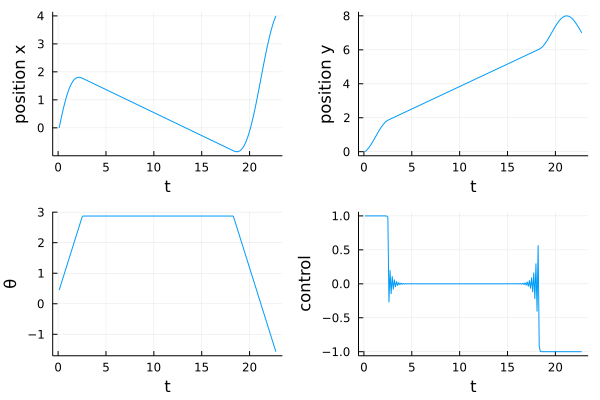

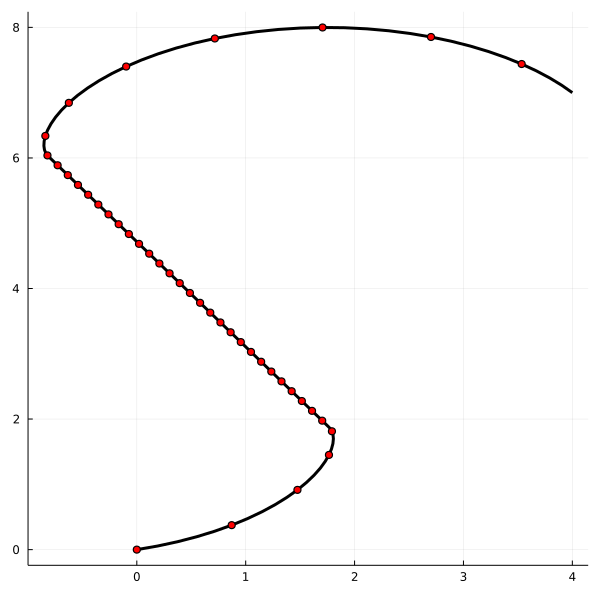

In [6]:
# Solves for the control and state
println("Solving...")
status = optimize!(sys)
println("Solver status : ",status)
x1 = value.(x)
y1 = value.(y)
θ1 = value.(θ)
u1 = value.(u)
println("Cost : " , objective_value(sys))
println("tf = ", value.(Δt)*P)

# Plots: states 
Δt1 = value.(Δt)
t = (1 : P)*Δt1
x_plot = plot(t,x1,xlabel = "t", ylabel = "position x", legend = false, fmt = :png)
y_plot = plot(t,y1,xlabel = "t", ylabel = "position y", legend = false, fmt = :png)
θ_plot = plot(t,θ1,xlabel = "t", ylabel = "θ", legend = false, fmt = :png)
u_plot = plot(t,u1,xlabel = "t", ylabel = "control", legend = false, fmt = :png)
display(plot(x_plot,y_plot,θ_plot,u_plot, layout = (2,2)))

# Plots: trajectory 
traj_plot = plot(x1,y1, c = :black, lw = 3)
plot!(size=(600,600))

for i = 1 : 5 : P 
    z = [x1[i] y1[i]]
    plot!([z[1]],[z[2]],seriestype = :scatter, color =:red , legend = false) 
    plot!(size=(600,600))
end
current()